In [2]:
import csv
import pandas as pd
import numpy as np
import tables as tb
import datetime

In [3]:
fn = 'data/AAPL.csv'

In [4]:
with open(fn, 'r') as f:
    for _ in range(5):
        print(f.readline(), end = '')

Date,HIGH,CLOSE,LOW,OPEN,COUNT,VOLUME
2020-04-01,248.72,240.91,239.13,246.5,460606.0,44054638.0
2020-04-02,245.15,244.93,236.9,240.34,380294.0,41483493.0
2020-04-03,245.7,241.41,238.9741,242.8,293699.0,32470017.0
2020-04-06,263.11,262.47,249.38,250.9,486681.0,50455071.0


In [5]:
csv_reader = csv.reader(open(fn, 'r'))

In [6]:
data = list(csv_reader)
data[:2]

[['Date', 'HIGH', 'CLOSE', 'LOW', 'OPEN', 'COUNT', 'VOLUME'],
 ['2020-04-01',
  '248.72',
  '240.91',
  '239.13',
  '246.5',
  '460606.0',
  '44054638.0']]

In [7]:
csv_reader = csv.DictReader(open(fn, 'r'))
data = list(csv_reader)

In [8]:
data[:3]

[{'Date': '2020-04-01',
  'HIGH': '248.72',
  'CLOSE': '240.91',
  'LOW': '239.13',
  'OPEN': '246.5',
  'COUNT': '460606.0',
  'VOLUME': '44054638.0'},
 {'Date': '2020-04-02',
  'HIGH': '245.15',
  'CLOSE': '244.93',
  'LOW': '236.9',
  'OPEN': '240.34',
  'COUNT': '380294.0',
  'VOLUME': '41483493.0'},
 {'Date': '2020-04-03',
  'HIGH': '245.7',
  'CLOSE': '241.41',
  'LOW': '238.9741',
  'OPEN': '242.8',
  'COUNT': '293699.0',
  'VOLUME': '32470017.0'}]

In [9]:
sum([float(l['CLOSE']) for l in data])/len(data)

272.3861904761905

In [10]:
data = pd.read_csv(fn, index_col = 0, parse_dates = True)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21 entries, 2020-04-01 to 2020-04-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HIGH    21 non-null     float64
 1   CLOSE   21 non-null     float64
 2   LOW     21 non-null     float64
 3   OPEN    21 non-null     float64
 4   COUNT   21 non-null     float64
 5   VOLUME  21 non-null     float64
dtypes: float64(6)
memory usage: 1.1 KB


In [12]:
data.head()

,HIGH,CLOSE,LOW,OPEN,COUNT,VOLUME
Date,,,,,,
2020-04-01,248.72,240.91,239.1300,246.50,460606.0,44054638.0
2020-04-02,245.15,244.93,236.9000,240.34,380294.0,41483493.0
2020-04-03,245.70,241.41,238.9741,242.80,293699.0,32470017.0
2020-04-06,263.11,262.47,249.3800,250.90,486681.0,50455071.0
2020-04-07,271.70,259.43,259.0000,270.80,467375.0,50721831.0


In [13]:
print(data['CLOSE'].mean())

272.38619047619056


In [14]:
data.to_json('data/aapl.json')

In [15]:
ls -n data/

total 1732872
drwxr-xr-x  3 501  20         96 27 Mar 08:31 __pycache__/
-rw-r--r--@ 1 501  20       1262 24 Mar 16:11 AAPL.csv
-rw-r--r--  1 501  20       3067 27 Mar 10:10 aapl.json
-rw-r--r--  1 501  20        401 27 Mar 08:26 data_loader_yves.py
-rw-r--r--  1 501  20         66 27 Mar 08:13 data_loader.py
-rw-r--r--  1 501  20  886968148 26 Mar 01:55 data.h5
-rw-r--r--@ 1 501  20     245030 26 Mar 03:00 pyalgo_eikon_eod_data.csv


In [16]:
ls data/

__pycache__/               data_loader.py
AAPL.csv                   data.h5
aapl.json                  pyalgo_eikon_eod_data.csv
data_loader_yves.py


In [17]:
ls -l data/

total 1732872
drwxr-xr-x  3 rohitoze  staff         96 27 Mar 08:31 __pycache__/
-rw-r--r--@ 1 rohitoze  staff       1262 24 Mar 16:11 AAPL.csv
-rw-r--r--  1 rohitoze  staff       3067 27 Mar 10:10 aapl.json
-rw-r--r--  1 rohitoze  staff        401 27 Mar 08:26 data_loader_yves.py
-rw-r--r--  1 rohitoze  staff         66 27 Mar 08:13 data_loader.py
-rw-r--r--  1 rohitoze  staff  886968148 26 Mar 01:55 data.h5
-rw-r--r--@ 1 rohitoze  staff     245030 26 Mar 03:00 pyalgo_eikon_eod_data.csv


In [18]:
data_copy = pd.read_json('data/aapl.json')

In [19]:
data_copy.head()

,HIGH,CLOSE,LOW,OPEN,COUNT,VOLUME
2020-04-01,248.72,240.91,239.1300,246.50,460606,44054638
2020-04-02,245.15,244.93,236.9000,240.34,380294,41483493
2020-04-03,245.70,241.41,238.9741,242.80,293699,32470017
2020-04-06,263.11,262.47,249.3800,250.90,486681,50455071
2020-04-07,271.70,259.43,259.0000,270.80,467375,50721831


In [20]:
import configparser
config = configparser.ConfigParser()
config.read('pyalgo.cfg')

['pyalgo.cfg']

In [21]:
print(config['quandl']['api_key'])
print(config.sections())

U9ULGy87VcszWRfWLUmB
['quandl']


In [22]:
import yfinance as yf
data = yf.download('BTC-USD')

[*********************100%***********************]  1 of 1 completed


In [23]:
data

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-02-27,65881.796875,68220.406250,64946.035156,67456.515625,40283655942
2026-02-28,66995.859375,67714.523438,63062.218750,65878.929688,42041497112
2026-03-01,65738.101562,68162.820312,65076.730469,67005.882812,40733141929
2026-03-02,68775.851562,70044.000000,65303.136719,65734.078125,56698092052
2026-03-03,68293.648438,69232.890625,66237.617188,68785.078125,47947999049
2026-03-04,72710.578125,74051.804688,67437.406250,68290.562500,75073101274
2026-03-05,70841.125000,73555.789062,70654.882812,72712.656250,51172841727
2026-03-06,68136.492188,71378.570312,67757.820312,70842.156250,43776962871


In [24]:
equities = ['AAPL', 'MSFT', 'GOOG']

In [25]:
data = yf.download(equities[0], start='2020-01-01', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [26]:
# data = data.xs('AAPL', level=1, axis=1).head()

In [27]:
ticker = yf.Ticker('AAPL')

In [28]:
expiries = ticker.options
expiries

('2026-03-27',
 '2026-03-30',
 '2026-04-01',
 '2026-04-02',
 '2026-04-10',
 '2026-04-17',
 '2026-04-24',
 '2026-05-01',
 '2026-05-15',
 '2026-06-18',
 '2026-07-17',
 '2026-08-21',
 '2026-09-18',
 '2026-10-16',
 '2026-11-20',
 '2026-12-18',
 '2027-01-15',
 '2027-03-19',
 '2027-06-17',
 '2027-12-17',
 '2028-01-21',
 '2028-03-17',
 '2028-12-15')

In [29]:
opt = ticker.option_chain(expiries[0])
calls = opt.calls
puts = opt.puts

In [30]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [31]:
data.keys()

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [32]:
from sample_data import generate_sample_data

In [33]:
print(generate_sample_data(rows=5, cols=4).round(4))

                       Col_0     Col_1     Col_2    Col_3
2021-01-01 00:00:00  99.5867   99.1794   99.2616  99.3956
2021-01-01 00:01:00  98.9532   98.8493   97.1513  98.2096
2021-01-01 00:02:00  98.2727   99.2667   96.4699  98.2952
2021-01-01 00:03:00  98.3325   99.5227   99.3588  97.4838
2021-01-01 00:04:00  99.4899  100.2224  100.0927  97.8759


In [34]:
%time data = generate_sample_data(rows=int(5e6), cols=10).round(4)

CPU times: user 1.18 s, sys: 3.36 s, total: 4.55 s
Wall time: 7.76 s


In [35]:
data.head()

,Col_0,Col_1,Col_2,Col_3,Col_4,Col_5,Col_6,Col_7,Col_8,Col_9
2021-01-01 00:00:00,99.2540,100.0765,99.7957,101.0260,99.6641,99.5931,100.5763,100.0919,100.8057,99.5578
2021-01-01 00:01:00,97.9929,100.4720,99.4389,101.4676,99.1535,97.6741,100.5883,99.0549,100.8010,100.0982
2021-01-01 00:02:00,98.2917,99.2384,100.7256,100.2586,99.4213,98.9407,100.7780,99.5498,99.5861,98.7797
2021-01-01 00:03:00,97.9125,98.7225,101.6728,99.1389,100.3274,98.1122,101.0129,98.7071,98.9404,98.3400
2021-01-01 00:04:00,97.8590,99.7985,101.5698,101.3355,100.5897,98.2861,100.6289,98.7378,99.4761,99.1251


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000000 entries, 2021-01-01 00:00:00 to 2030-07-05 05:19:00
Freq: min
Data columns (total 10 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Col_0   float64
 1   Col_1   float64
 2   Col_2   float64
 3   Col_3   float64
 4   Col_4   float64
 5   Col_5   float64
 6   Col_6   float64
 7   Col_7   float64
 8   Col_8   float64
 9   Col_9   float64
dtypes: float64(10)
memory usage: 419.6 MB


In [37]:
h5 = pd.HDFStore('data/data.h5', 'w')

In [38]:
%time h5['data'] = data

CPU times: user 6.31 ms, sys: 240 ms, total: 247 ms
Wall time: 404 ms


In [39]:
%time data_copy = h5['data']

CPU times: user 168 ms, sys: 466 ms, total: 635 ms
Wall time: 1.36 s


In [40]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000000 entries, 2021-01-01 00:00:00 to 2030-07-05 05:19:00
Freq: min
Data columns (total 10 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Col_0   float64
 1   Col_1   float64
 2   Col_2   float64
 3   Col_3   float64
 4   Col_4   float64
 5   Col_5   float64
 6   Col_6   float64
 7   Col_7   float64
 8   Col_8   float64
 9   Col_9   float64
dtypes: float64(10)
memory usage: 419.6 MB


In [41]:
%time data.to_csv('data/sample_data.csv')

CPU times: user 26 s, sys: 1.41 s, total: 27.4 s
Wall time: 29.8 s


In [42]:
%time data_copy_csv = pd.read_csv('data/sample_data.csv')

CPU times: user 3.58 s, sys: 820 ms, total: 4.4 s
Wall time: 4.85 s


In [43]:
%time data.to_hdf('data/data.h5', 'data', format='table')

<timed eval>:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.


CPU times: user 3.4 s, sys: 1.48 s, total: 4.88 s
Wall time: 5.47 s


In [44]:
h5.close()
%time data_copy = pd.read_hdf('data/data.h5', 'data')

CPU times: user 75.2 ms, sys: 200 ms, total: 276 ms
Wall time: 415 ms


In [45]:
h5 = tb.open_file('data/data.h5', 'r')

In [46]:
h5.close()

In [47]:
start = datetime.datetime(2021, 1, 2)
end = datetime.datetime(2021, 1, 3)
# start?

The vectorized backtesting approach clearly has limits when it comes to the modeling of algorithmic trading strategies. However, many popular, simple strategies can be backtested in vectorized fashion.

Vectorized backtesting is pretty fast in general, allowing one to test a great variety of parameter combinations in a short amount of time. When speed is key, the approach should be considered.

In [48]:
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [49]:
a.mean(axis=1)

array([1.5, 5.5, 9.5])

In [50]:
raw = pd.read_csv('data/pyalgo_eikon_eod_data.csv', index_col=0, parse_dates=True).dropna()

In [51]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2010-01-04 to 2019-12-31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2516 non-null   float64
 1   MSFT.O  2516 non-null   float64
 2   INTC.O  2516 non-null   float64
 3   AMZN.O  2516 non-null   float64
 4   GS.N    2516 non-null   float64
 5   SPY     2516 non-null   float64
 6   .SPX    2516 non-null   float64
 7   .VIX    2516 non-null   float64
 8   EUR=    2516 non-null   float64
 9   XAU=    2516 non-null   float64
 10  GDX     2516 non-null   float64
 11  GLD     2516 non-null   float64
dtypes: float64(12)
memory usage: 255.5 KB


In [52]:
data = pd.DataFrame(raw['EUR='])

In [57]:
data.rename(columns={'EUR=' : 'EUR/USD'}, inplace=True)

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2010-01-04 to 2019-12-31
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   EUR/USD  2516 non-null   float64
dtypes: float64(1)
memory usage: 39.3 KB


In [59]:
data.head(15)

,EUR/USD
Date,
2010-01-04,1.4411
2010-01-05,1.4368
2010-01-06,1.4412
2010-01-07,1.4318
2010-01-08,1.4412
2010-01-11,1.4513
2010-01-12,1.4494
2010-01-13,1.4510
2010-01-14,1.4502


In [60]:
data['SMA1'] = data['EUR/USD'].rolling(42).mean()
data['SMA2'] = data['EUR/USD'].rolling(252).mean()
data.head(15)

,EUR/USD,SMA1,SMA2
Date,,,
2010-01-04,1.4411,NaN,NaN
2010-01-05,1.4368,NaN,NaN
2010-01-06,1.4412,NaN,NaN
2010-01-07,1.4318,NaN,NaN
2010-01-08,1.4412,NaN,NaN
2010-01-11,1.4513,NaN,NaN
2010-01-12,1.4494,NaN,NaN
2010-01-13,1.4510,NaN,NaN
2010-01-14,1.4502,NaN,NaN


In [61]:
data.iloc[252]

EUR/USD    1.335100
SMA1       1.340945
SMA2       1.325798
Name: 2011-01-03 00:00:00, dtype: float64

In [62]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'

<Axes: title={'center': 'EUR/USD | 42 & 252 days moving average'}, xlabel='Date'>

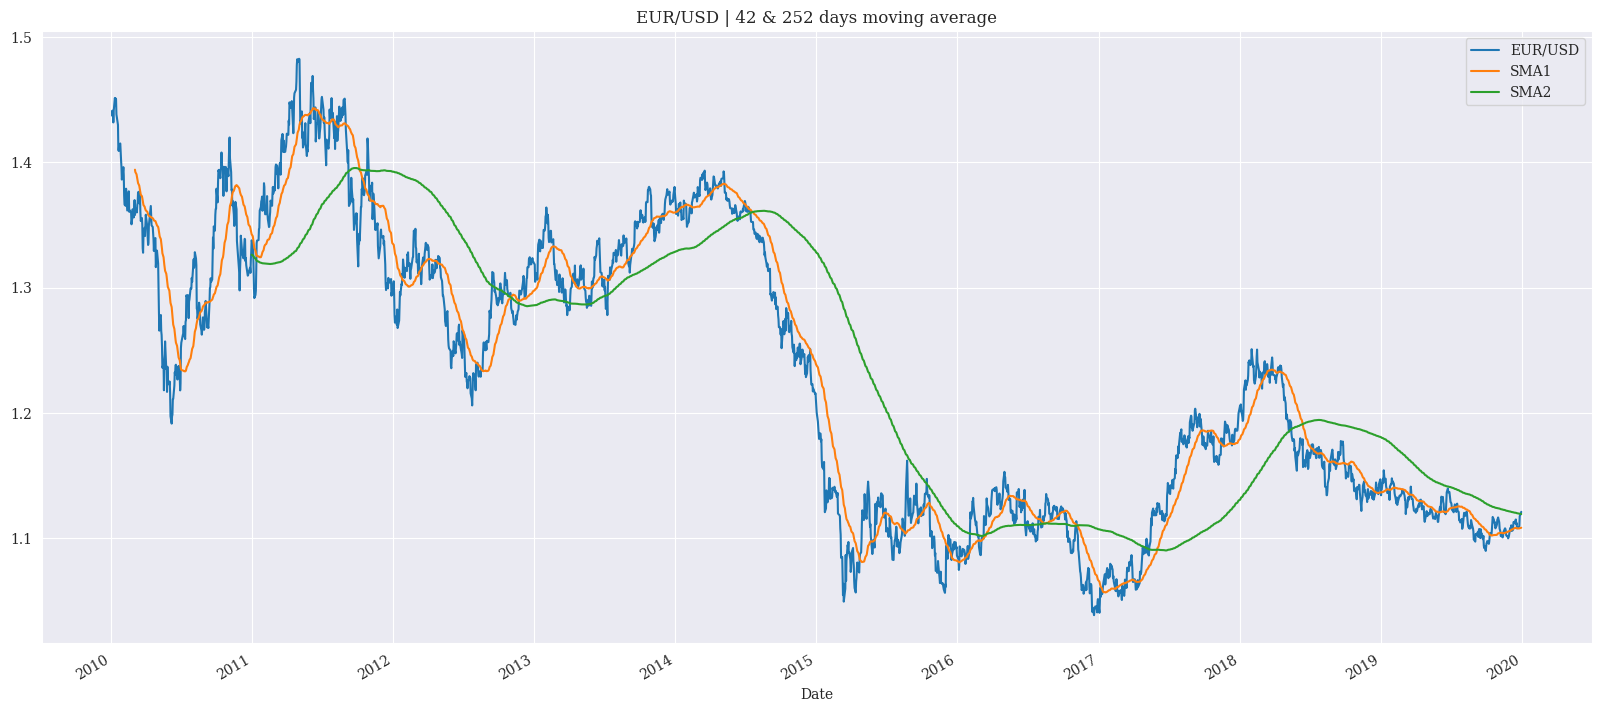

In [63]:
data.plot(title = 'EUR/USD | 42 & 252 days moving average', figsize=(20,9))

In [64]:
data['position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)

In [65]:
data.dropna(inplace=True)

In [66]:
data.head(10)

,EUR/USD,SMA1,SMA2,position
Date,,,,
2010-12-31,1.3377,1.342579,1.326218,1
2011-01-03,1.3351,1.340945,1.325798,1
2011-01-04,1.3301,1.338940,1.325374,1
2011-01-05,1.3151,1.336448,1.324874,1
2011-01-06,1.3001,1.333995,1.324351,1
2011-01-07,1.2916,1.331602,1.323758,1
2011-01-10,1.2941,1.329612,1.323134,1
2011-01-11,1.2975,1.327690,1.322531,1
2011-01-12,1.3135,1.326452,1.321985,1


<Axes: title={'center': 'Market Positioning'}, xlabel='Date'>

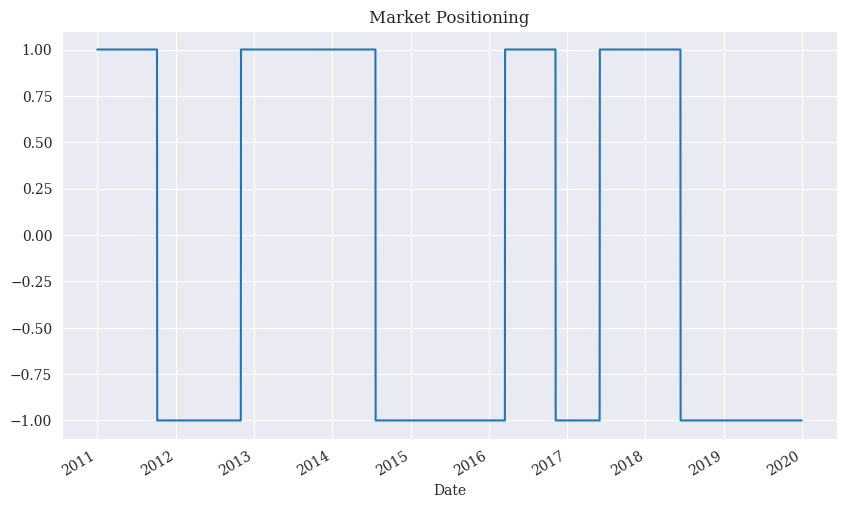

In [67]:
data['position'].plot(ylim=[-1.1,1.1], title='Market Positioning', figsize=(10,6))

In [68]:
# Calculating everyday log returns as they are addtive 
data['returns'] = np.log(data['EUR/USD'] / data['EUR/USD'].shift(1))

<Axes: >

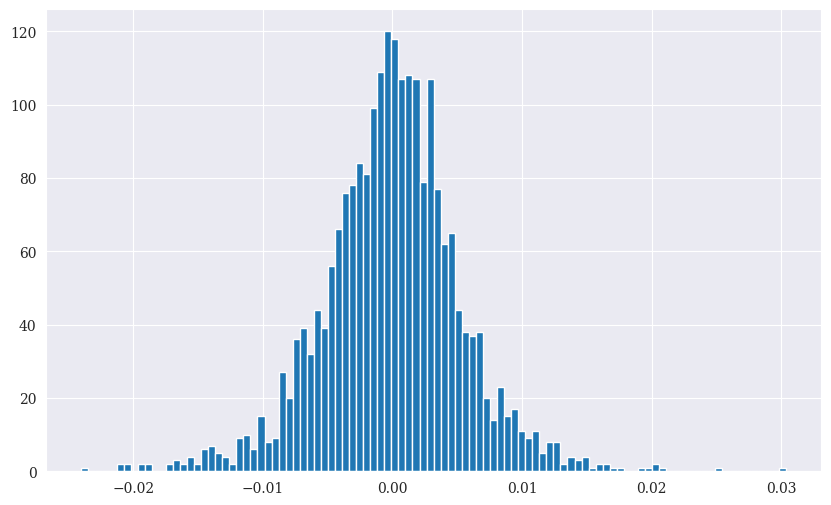

In [69]:
data['returns'].hist(bins=100, figsize=(10,6))

In [70]:
# Applying the strategy to the existing data. Got to shift(1) as current time T strategy will be applied on T+1
data['strategy'] = data['position'].shift(1) * data['returns']

In [71]:
data.head()

,EUR/USD,SMA1,SMA2,position,returns,strategy
Date,,,,,,
2010-12-31,1.3377,1.342579,1.326218,1,NaN,NaN
2011-01-03,1.3351,1.340945,1.325798,1,-0.001946,-0.001946
2011-01-04,1.3301,1.338940,1.325374,1,-0.003752,-0.003752
2011-01-05,1.3151,1.336448,1.324874,1,-0.011341,-0.011341
2011-01-06,1.3001,1.333995,1.324351,1,-0.011472,-0.011472


In [72]:
data[['returns', 'strategy']].sum()

returns    -0.176731
strategy    0.253121
dtype: float64

<Axes: title={'center': 'SMA based strategy performance of EUR/USD'}, xlabel='Date'>

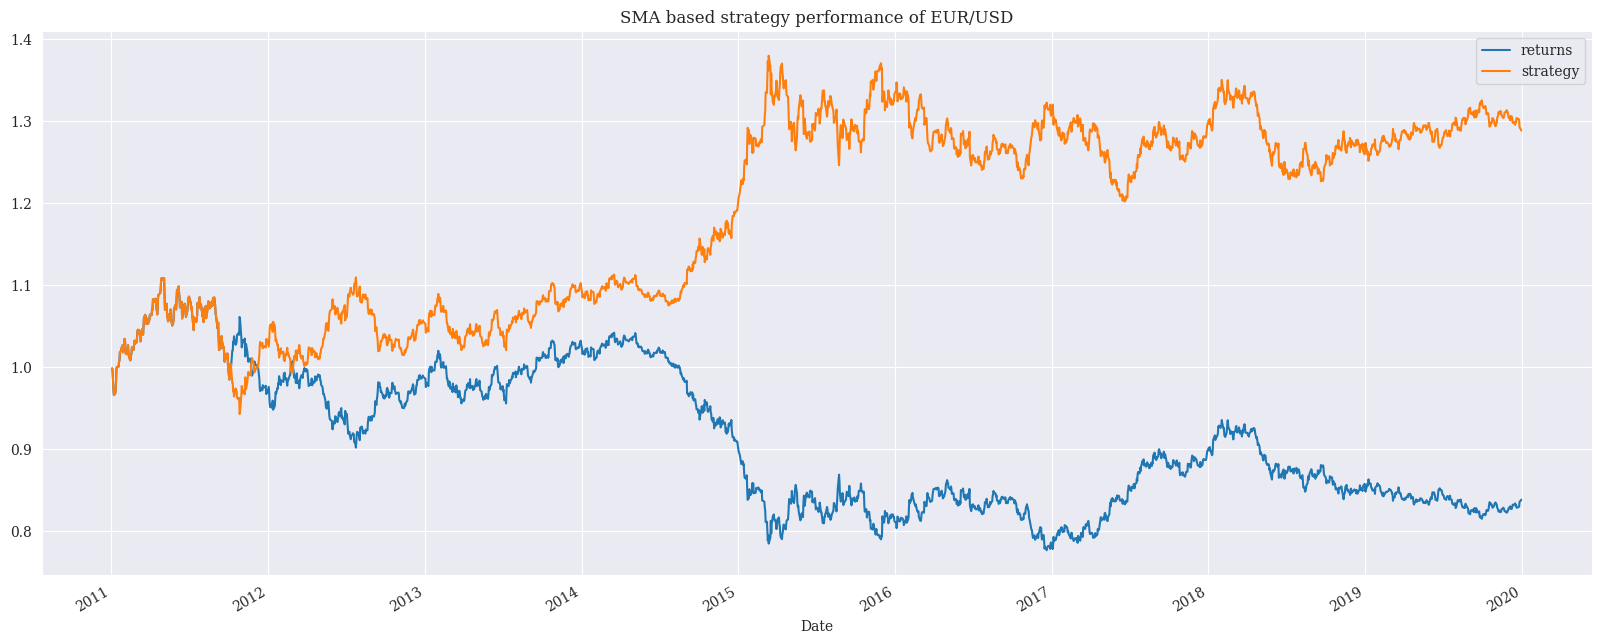

In [73]:
# Plotting graph of strategy based returns of EUR/USD
data[['returns', 'strategy']].cumsum().apply(np.exp).plot(title='SMA based strategy performance of EUR/USD' , figsize=(20,8))

In [74]:
# Annualized Mean log for strategy and returns
data[['returns', 'strategy']].mean()*252

returns    -0.019671
strategy    0.028174
dtype: float64

In [75]:
#Annualized for returns and strategy

var = np.exp(data[['returns', 'strategy']].mean() * 252) - 1
print(var['returns'].round(6), var['strategy'].round(6), sep='\n')

-0.019479
0.028575


In [76]:
#Annualized standard deviation in log and regular space
data[['returns', 'strategy']].std() * (252 ** 0.5)
(np.exp(data[['returns', 'strategy']]) - 1).std() * 252 ** 0.5

returns     0.085405
strategy    0.085373
dtype: float64

In [77]:
data.head()

,EUR/USD,SMA1,SMA2,position,returns,strategy
Date,,,,,,
2010-12-31,1.3377,1.342579,1.326218,1,NaN,NaN
2011-01-03,1.3351,1.340945,1.325798,1,-0.001946,-0.001946
2011-01-04,1.3301,1.338940,1.325374,1,-0.003752,-0.003752
2011-01-05,1.3151,1.336448,1.324874,1,-0.011341,-0.011341
2011-01-06,1.3001,1.333995,1.324351,1,-0.011472,-0.011472


In [78]:
data['cum_returns'] = data['strategy'].cumsum().apply(np.exp)
data['cum_max'] = data['cum_returns'].cummax()

In [79]:
data[['cum_returns', 'cum_max']].dropna()

,cum_returns,cum_max
Date,,
2011-01-03,0.998056,0.998056
2011-01-04,0.994319,0.998056
2011-01-05,0.983105,0.998056
2011-01-06,0.971892,0.998056
2011-01-07,0.965538,0.998056
...,...,...
2019-12-24,1.302328,1.379350
2019-12-26,1.301272,1.379350
2019-12-27,1.292073,1.379350


Maximum drawdown: The largest peak-to-trough decline in your portfolio over a period.

It answers what's the worst loss I would have experienced if I invested in this strategy?

In [80]:
drawdown = data['cum_max'] - data['cum_returns']
drawdown.max()

np.float64(0.17779367070195895)

In [81]:
import SMAVectorBacktester as SMA

In [82]:
smabt = SMA.SMAVectorBacktester('EUR=', 42, 252, '2010-1-1', '2019-12-31')

In [83]:
smabt.run_strategy()

(np.float64(1.29), np.float64(0.45))

In [84]:
%%time
smabt.optimize_parameters((30,50,2), (200,300,2))

CPU times: user 839 ms, sys: 46.1 ms, total: 886 ms
Wall time: 1.27 s


(array([ 48., 238.]), np.float64(1.5))

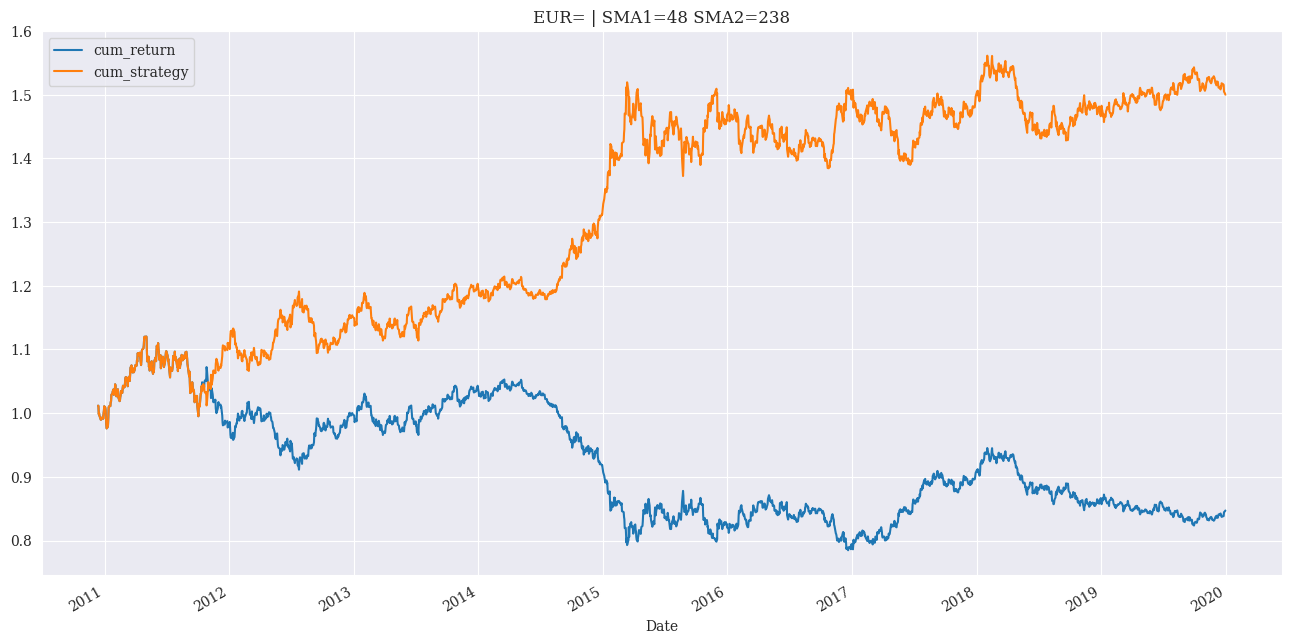

In [85]:
smabt.plot_results()

In [86]:
data.head()

,EUR/USD,SMA1,SMA2,position,returns,strategy,cum_returns,cum_max
Date,,,,,,,,
2010-12-31,1.3377,1.342579,1.326218,1,NaN,NaN,NaN,NaN
2011-01-03,1.3351,1.340945,1.325798,1,-0.001946,-0.001946,0.998056,0.998056
2011-01-04,1.3301,1.338940,1.325374,1,-0.003752,-0.003752,0.994319,0.998056
2011-01-05,1.3151,1.336448,1.324874,1,-0.011341,-0.011341,0.983105,0.998056
2011-01-06,1.3001,1.333995,1.324351,1,-0.011472,-0.011472,0.971892,0.998056


In [87]:
data['trades'] = data['position'].diff().abs()

In [90]:
data['trades'].head()

Date
2010-12-31    NaN
2011-01-03    0.0
2011-01-04    0.0
2011-01-05    0.0
2011-01-06    0.0
Name: trades, dtype: float64

In [1]:
from data.data_loader_yves import load_data_yves
from strategy.sma_strategy import SMAStrategy
from backtester.backtester import Backtester

In [2]:
data = load_data_yves('EUR=', '2010-1-1', '2020-12-31')

             price
Date              
2010-01-04  1.4411
2010-01-05  1.4368
2010-01-06  1.4412
2010-01-07  1.4318
2010-01-08  1.4412


In [4]:
strategy = SMAStrategy(42, 252)

In [5]:
bt = Backtester(data, strategy)


In [6]:
results = bt.run()
print(results.head())

             price    return   returns  signal  strategy  trades  cum_return  \
Date                                                                           
2010-01-05  1.4368 -0.002988 -0.002988      -1  0.002988     0.0    0.997016   
2010-01-06  1.4412  0.003058  0.003058      -1 -0.003058     0.0    1.000069   
2010-01-07  1.4318 -0.006544 -0.006544      -1  0.006544     0.0    0.993547   
2010-01-08  1.4412  0.006544  0.006544      -1 -0.006544     0.0    1.000069   
2010-01-11  1.4513  0.006984  0.006984      -1 -0.006984     0.0    1.007078   

            cum_strategy   cum_max  drawdown  
Date                                          
2010-01-05      1.002993  1.002993 -0.005959  
2010-01-06      0.999931  1.002993  0.000139  
2010-01-07      1.006495  1.006495 -0.012865  
2010-01-08      0.999931  1.006495  0.000139  
2010-01-11      0.992972  1.006495  0.014206  


In [21]:
results = bt.performance()
# type(results)
for key, value in results.items():
    print(key, value, sep=': ')

Total Return: 0.3656
Sharpe: 0.3485
Max Drawdown: -0.5061


In [8]:
total_return = results['cum_strategy'].iloc[-1] - 1
print(total_return)

0.3655751056115104
